# Multi-Dataset Similarity Distribution Analysis (HuggingFace Edition) v2
## Understanding Model-Dataset Interactions in LMDFit

This notebook analyzes how different models produce cosine similarity distributions across multiple datasets.

**Updates in v2:**
- Added k-means clustering (k=2) to classify models as "more-fit" or "less-fit" per dataset
- Reorganized outputs: CSV files saved per dataset (containing all 7 models)
- Visualizations show all models overlaid per dataset
- Results organized into `results/csv/` and `results/visualizations/` folders
- Uses adjusted Fisher-Pearson coefficient of skewness (scipy's `bias=False`)

In [1]:
# Install required packages if needed
#pip install datasets transformers torch scipy pandas matplotlib seaborn scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertModel, BertTokenizer
import torch
from scipy.stats import skew, kurtosis, gaussian_kde
from sklearn.cluster import KMeans
from datasets import load_dataset
import warnings
import os
import gc
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directories
os.makedirs('results/csv', exist_ok=True)
os.makedirs('results/visualizations', exist_ok=True)
print("\n✅ Output directories created:")
print("  - results/csv/")
print("  - results/visualizations/")

Using device: cuda

✅ Output directories created:
  - results/csv/
  - results/visualizations/


## 1. Define Models and Datasets Configuration

In [3]:
# Models from the paper
models_config = {
    'BERT': 'google-bert/bert-base-uncased',
    'SciBERT': 'allenai/scibert_scivocab_uncased',
    'LegalBERT': 'nlpaueb/legal-bert-base-uncased',
    'FinancialBERT': 'ahmedrachid/FinancialBERT',
    'PharmBERT': 'Lianglab/PharmBERT-uncased',
    'AgricultureBERT': 'recobo/agriculture-bert-uncased',
    'ChemicalBERT': 'recobo/chemical-bert-uncased'
}

# Dataset configurations with HuggingFace paths
datasets_config = {
    'ECtHR': {
        'source': 'huggingface',
        'path': 'AUEB-NLP/ecthr_cases',
        'subset': None,
        'split': 'train',
        'text_column': 'facts',
        'label_column': 'labels'
    },
    
    'Financial': {
        'source': 'huggingface',
        'path': 'takala/financial_phrasebank',
        'subset': 'sentences_50agree',
        'split': 'train',
        'text_column': 'sentence',
        'label_column': 'label'
    },
    
    'Climate_Detection': {
        'source': 'huggingface',
        'path': 'climatebert/climate_detection',
        'subset': None,
        'split': 'train',
        'text_column': 'text',
        'label_column': 'label'
    },
    
    'ADE_Corpus': {
        'source': 'huggingface',
        'path': 'SetFit/ade_corpus_v2_classification',
        'subset': 'Ade_corpus_v2_classification',
        'split': 'train',
        'text_column': 'text',
        'label_column': 'label'
    },
    
    'DrugReviews': {
        'source': 'huggingface',
        'path': 'forwins/Drug-Review-Dataset',
        'subset': None,
        'split': 'train',
        'text_column': 'review',
        'label_column': 'rating'
    }
}

print("✅ Configuration loaded successfully!")
print(f"\n📊 Datasets to analyze: {list(datasets_config.keys())}")
print(f"🤖 Models to test: {list(models_config.keys())}")

✅ Configuration loaded successfully!

📊 Datasets to analyze: ['ECtHR', 'Financial', 'Climate_Detection', 'ADE_Corpus', 'DrugReviews']
🤖 Models to test: ['BERT', 'SciBERT', 'LegalBERT', 'FinancialBERT', 'PharmBERT', 'AgricultureBERT', 'ChemicalBERT']


## 2. Dataset Loading and Sampling Functions

In [4]:
def load_dataset_from_config(dataset_config):
    """
    Load dataset from HuggingFace
    
    Returns:
        pandas DataFrame with text column, text_column name
    """
    if dataset_config['source'] == 'huggingface':
        print(f"  Loading from HuggingFace: {dataset_config['path']}")
        
        if dataset_config['subset']:
            print(f"  Subset: {dataset_config['subset']}")
            dataset = load_dataset(
                dataset_config['path'],
                dataset_config['subset'],
                split=dataset_config['split']
            )
        else:
            dataset = load_dataset(
                dataset_config['path'],
                split=dataset_config['split']
            )
        
        df = pd.DataFrame(dataset)
        text_column = dataset_config['text_column']
        
        print(f"  ✅ Loaded {len(df)} samples")
        print(f"  Columns: {list(df.columns)}")
        print(f"  Using text column: '{text_column}'")
        
        return df, text_column
    else:
        raise ValueError(f"Unknown source: {dataset_config['source']}")


def clean_text(text):
    """Clean text by removing extra whitespace and handling special cases"""
    if isinstance(text, list):
        text = ' '.join(text)
    if not isinstance(text, str):
        text = str(text)
    import re
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def stratified_sample(df, text_column, sample_size=200, max_strata=100, min_strata=10):
    """
    Stratified quota sampling based on text length.
    Following the paper's approach with adaptive strata.
    """
    try:
        df = df.copy()
        df['length'] = df[text_column].apply(lambda x: len(str(x).split()))
        
        # Remove empty texts
        df = df[df['length'] > 0]
        
        if len(df) < sample_size:
            print(f"  ⚠️ Dataset has only {len(df)} samples, using all")
            return df[text_column].tolist()
        
        # Adaptive strata calculation
        n_strata = min(max_strata, max(min_strata, len(df) // 20))
        
        # Create strata based on quantiles
        df['strata'] = pd.qcut(df['length'], q=n_strata, labels=False, duplicates='drop')
        
        num_actual_strata = len(df['strata'].unique())
        n_per_stratum = sample_size // num_actual_strata
        
        strata_sizes = df.groupby('strata').size()
        min_samples = strata_sizes.min()
        
        if min_samples < n_per_stratum:
            n_per_stratum = max(1, min_samples)
            print(f"  ⚠️ Adjusted to {n_per_stratum} samples per stratum")
        
        if n_per_stratum < 1:
            print(f"  ⚠️ Too many strata. Using random sampling.")
            sampled = df.sample(n=min(sample_size, len(df)), random_state=42)
        else:
            print(f"  Sampling {n_per_stratum} texts from each of {num_actual_strata} strata...")
            sampled = df.groupby('strata', group_keys=False).apply(
                lambda x: x.sample(min(len(x), n_per_stratum), random_state=42)
            ).reset_index(drop=True)
        
        print(f"  ✅ Sampled {len(sampled)} texts")
        return sampled[text_column].tolist()
        
    except Exception as e:
        print(f"  ⚠️ Stratification failed: {e}")
        sampled = df.sample(n=min(sample_size, len(df)), random_state=42)
        return sampled[text_column].tolist()

## 3. Embedding and Similarity Computation

In [5]:
def compute_embeddings(texts, model, tokenizer, max_length=512, batch_size=32):
    """
    Compute embeddings for a list of texts using mean pooling of last hidden state
    """
    model.eval()
    model = model.to(device)
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts, 
            return_tensors="pt", 
            padding=True, 
            max_length=max_length, 
            truncation=True
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state.mean(dim=1)
            embeddings.append(batch_embeddings.cpu())
    
    return torch.cat(embeddings, dim=0)


def compute_cosine_similarities(embeddings):
    """
    Compute pairwise cosine similarities (upper triangle only, excluding self-pairs)
    This matches the paper's approach.
    """
    n = embeddings.shape[0]
    similarities = []
    
    # Normalize embeddings
    embeddings_norm = torch.nn.functional.normalize(embeddings, p=2, dim=1)
    
    # Compute all pairwise similarities (upper triangle only)
    for i in range(n):
        for j in range(i+1, n):
            sim = torch.dot(embeddings_norm[i], embeddings_norm[j]).item()
            similarities.append(sim)
    
    print(f"  Computed {len(similarities)} pairwise similarities")
    return np.array(similarities)

## 4. K-Means Clustering Function (LMDFit Algorithm)

This implements the clustering from the paper:
- k=2 clusters based on (mean, skewness) two-vector
- The cluster with average skewness closer to 0 is labeled "more-fit"

In [6]:
def cluster_models_lmdfit(dataset_results):
    """
    Apply k-means clustering (k=2) to categorize models as 'more-fit' or 'less-fit'
    based on their (mean, skewness) two-vector.
    
    Following the LMDFit paper:
    - The cluster with average skewness closer to 0 is labeled 'more-fit'
    
    Args:
        dataset_results: dict with model names as keys and stats dicts as values
        
    Returns:
        dict with clustering results including labels and cluster assignments
    """
    model_names = list(dataset_results.keys())
    
    # Extract mean and skewness for each model
    means = np.array([dataset_results[m]['mean'] for m in model_names])
    skewnesses = np.array([dataset_results[m]['skewness'] for m in model_names])
    
    # Create feature matrix (mean, skewness)
    X = np.column_stack([means, skewnesses])
    
    # Apply k-means with k=2
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    # Determine which cluster is 'more-fit' (average skewness closer to 0)
    cluster_0_skew = skewnesses[cluster_labels == 0].mean()
    cluster_1_skew = skewnesses[cluster_labels == 1].mean()
    
    # The cluster with skewness closer to 0 is 'more-fit'
    if abs(cluster_0_skew) < abs(cluster_1_skew):
        more_fit_cluster = 0
    else:
        more_fit_cluster = 1
    
    # Create results
    clustering_results = {
        'model_names': model_names,
        'means': means,
        'skewnesses': skewnesses,
        'cluster_labels': cluster_labels,
        'more_fit_cluster': more_fit_cluster,
        'centroids': kmeans.cluster_centers_,
        'fit_labels': ['more-fit' if label == more_fit_cluster else 'less-fit' 
                       for label in cluster_labels]
    }
    
    # Print results
    print("\n  📊 Clustering Results:")
    print(f"  Cluster 0 avg skewness: {cluster_0_skew:.4f}")
    print(f"  Cluster 1 avg skewness: {cluster_1_skew:.4f}")
    print(f"  More-fit cluster: {more_fit_cluster}")
    print("\n  Model Classifications:")
    for i, model in enumerate(model_names):
        fit_label = clustering_results['fit_labels'][i]
        marker = "✅" if fit_label == 'more-fit' else "❌"
        print(f"    {marker} {model}: {fit_label} (mean={means[i]:.4f}, skew={skewnesses[i]:.4f})")
    
    return clustering_results

## 5. Visualization Functions

In [7]:
def plot_dataset_distributions(dataset_name, dataset_results, clustering_results=None):
    """
    Create visualization for ONE dataset showing ALL models.
    Similar to Figure 4a in the paper - overlaid distributions.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{dataset_name}: Similarity Distributions Across All Models', 
                 fontsize=16, fontweight='bold')
    
    model_names = list(dataset_results.keys())
    colors = sns.color_palette('husl', len(model_names))
    
    # Plot 1: Overlaid histograms
    ax1 = axes[0, 0]
    for idx, (model_name, stats) in enumerate(dataset_results.items()):
        ax1.hist(stats['similarities'], bins=50, alpha=0.4, label=model_name,
                color=colors[idx], density=True)
    ax1.set_xlabel('Cosine Similarity', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.set_title('Overlaid Distributions (Histograms)', fontsize=14)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    
    # Plot 2: KDE plots (smoother)
    ax2 = axes[0, 1]
    for idx, (model_name, stats) in enumerate(dataset_results.items()):
        kde = gaussian_kde(stats['similarities'])
        x_range = np.linspace(0, 1, 1000)
        ax2.plot(x_range, kde(x_range), label=model_name, color=colors[idx], linewidth=2)
    ax2.set_xlabel('Cosine Similarity', fontsize=12)
    ax2.set_ylabel('Density', fontsize=12)
    ax2.set_title('Kernel Density Estimates', fontsize=14)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 1)
    
    # Plot 3: Mean vs Skewness scatter (LMDFit clustering space)
    ax3 = axes[1, 0]
    means = [stats['mean'] for stats in dataset_results.values()]
    skewnesses = [stats['skewness'] for stats in dataset_results.values()]
    
    if clustering_results is not None:
        # Color by cluster assignment
        for i, model in enumerate(model_names):
            fit_label = clustering_results['fit_labels'][i]
            color = 'green' if fit_label == 'more-fit' else 'red'
            marker = 'o' if fit_label == 'more-fit' else 'x'
            ax3.scatter(skewnesses[i], means[i], s=200, c=color, marker=marker,
                       alpha=0.7, edgecolors='black', linewidth=2, label=f"{model} ({fit_label})")
    else:
        ax3.scatter(skewnesses, means, s=200, c=colors, alpha=0.7, 
                   edgecolors='black', linewidth=2)
        for i, name in enumerate(model_names):
            ax3.annotate(name, (skewnesses[i], means[i]), fontsize=10,
                        xytext=(5, 5), textcoords='offset points')
    
    ax3.set_xlabel('Skewness', fontsize=12)
    ax3.set_ylabel('Mean Similarity', fontsize=12)
    ax3.set_title('LMDFit Clustering Space (Mean vs Skewness)', fontsize=14)
    ax3.grid(True, alpha=0.3)
    
    # Add legend for clustering
    if clustering_results is not None:
        handles = [
            plt.scatter([], [], c='green', marker='o', s=100, label='More-fit'),
            plt.scatter([], [], c='red', marker='x', s=100, label='Less-fit')
        ]
        ax3.legend(handles=handles, loc='upper right')
        # Add model names as annotations
        for i, name in enumerate(model_names):
            ax3.annotate(name, (skewnesses[i], means[i]), fontsize=9,
                        xytext=(5, 5), textcoords='offset points')
    
    # Plot 4: Box plots
    ax4 = axes[1, 1]
    box_data = [stats['similarities'] for stats in dataset_results.values()]
    bp = ax4.boxplot(box_data, labels=model_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax4.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    ax4.set_ylabel('Cosine Similarity', fontsize=12)
    ax4.set_title('Distribution Comparison (Box Plots)', fontsize=14)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 1)
    
    plt.tight_layout()
    return fig


def plot_clustering_scatter(dataset_name, clustering_results):
    """
    Create a dedicated clustering visualization similar to Figure 4b/Figure 6 in the paper.
    Scatter plot showing mean vs skewness with cluster assignments.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    model_names = clustering_results['model_names']
    means = clustering_results['means']
    skewnesses = clustering_results['skewnesses']
    fit_labels = clustering_results['fit_labels']
    centroids = clustering_results['centroids']
    
    # Plot each model
    for i, model in enumerate(model_names):
        color = 'green' if fit_labels[i] == 'more-fit' else 'red'
        marker = 'o' if fit_labels[i] == 'more-fit' else 's'
        ax.scatter(skewnesses[i], means[i], s=200, c=color, marker=marker,
                  alpha=0.8, edgecolors='black', linewidth=2)
        ax.annotate(model, (skewnesses[i], means[i]), fontsize=11,
                   xytext=(8, 8), textcoords='offset points', fontweight='bold')
    
    # Plot centroids
    more_fit_cluster = clustering_results['more_fit_cluster']
    for c_idx, centroid in enumerate(centroids):
        color = 'green' if c_idx == more_fit_cluster else 'red'
        ax.scatter(centroid[1], centroid[0], s=300, c=color, marker='*',
                  edgecolors='black', linewidth=2, zorder=5)
    
    # Add decision boundary hint (diagonal line)
    ax.axhline(y=np.mean(means), color='gray', linestyle='--', alpha=0.5, label='Mean threshold')
    
    ax.set_xlabel('Skewness', fontsize=14)
    ax.set_ylabel('Mean Similarity', fontsize=14)
    ax.set_title(f'{dataset_name}: Model Initial Selection Results\n(LMDFit Clustering)', 
                fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Legend
    legend_elements = [
        plt.scatter([], [], c='green', marker='o', s=150, label='More-fit models'),
        plt.scatter([], [], c='red', marker='s', s=150, label='Less-fit models'),
        plt.scatter([], [], c='gray', marker='*', s=200, label='Cluster centroids')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    return fig

## 6. CSV Export Functions

In [8]:
def save_dataset_results_csv(dataset_name, dataset_results, clustering_results):
    """
    Save results for one dataset (all 7 models) to a CSV file.
    Includes clustering labels.
    """
    rows = []
    model_names = clustering_results['model_names']
    fit_labels = clustering_results['fit_labels']
    
    for i, model_name in enumerate(model_names):
        stats = dataset_results[model_name]
        rows.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'Mean': round(stats['mean'], 4),
            'Std': round(stats['std'], 4),
            'Skewness': round(stats['skewness'], 4),
            'Kurtosis': round(stats['kurtosis'], 4),
            'Median': round(stats['median'], 4),
            'Q25': round(stats['q25'], 4),
            'Q75': round(stats['q75'], 4),
            'Min': round(stats['min'], 4),
            'Max': round(stats['max'], 4),
            'Fit_Label': fit_labels[i]
        })
    
    df = pd.DataFrame(rows)
    
    # Sort by Mean (ascending) as in the paper tables
    df = df.sort_values('Mean', ascending=True)
    
    filepath = f'results/csv/{dataset_name}_results.csv'
    df.to_csv(filepath, index=False)
    print(f"  📊 Saved: {filepath}")
    
    return df

## 7. Main Analysis Function (Dataset-Centric)

In [9]:
def analyze_dataset_across_models(dataset_name, dataset_config, models_config, sample_size=200):
    """
    For ONE dataset, compute similarity distributions for ALL models.
    Then apply clustering to categorize models.
    
    This is the dataset-centric view (opposite of model-centric).
    """
    print(f"\n{'='*80}")
    print(f"Analyzing Dataset: {dataset_name}")
    print(f"{'='*80}")
    
    # Load and sample dataset ONCE
    print(f"\nLoading dataset...")
    df, text_column = load_dataset_from_config(dataset_config)
    texts = stratified_sample(df, text_column, sample_size)
    texts_clean = [clean_text(t) for t in texts]
    
    results = {}
    
    # Analyze each model on this dataset
    for model_name, model_path in models_config.items():
        print(f"\n{'─'*60}")
        print(f"Processing model: {model_name}")
        
        try:
            # Load model
            tokenizer = BertTokenizer.from_pretrained(model_path)
            model = BertModel.from_pretrained(model_path)
            
            # Compute embeddings
            print(f"  Computing embeddings...")
            embeddings = compute_embeddings(texts_clean, model, tokenizer)
            
            # Compute similarities
            print(f"  Computing pairwise cosine similarities...")
            similarities = compute_cosine_similarities(embeddings)
            
            # Compute statistics
            # Note: Using bias=False for adjusted Fisher-Pearson coefficient
            stats = {
                'similarities': similarities,
                'mean': np.mean(similarities),
                'std': np.std(similarities),
                'skewness': skew(similarities, bias=False),  # Adjusted Fisher-Pearson
                'kurtosis': kurtosis(similarities, bias=False),
                'median': np.median(similarities),
                'q25': np.percentile(similarities, 25),
                'q75': np.percentile(similarities, 75),
                'min': np.min(similarities),
                'max': np.max(similarities)
            }
            
            results[model_name] = stats
            print(f"  ✅ Mean: {stats['mean']:.4f}, Skewness: {stats['skewness']:.4f}")
            
            # Clear model from GPU
            del model, tokenizer, embeddings
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                
        except Exception as e:
            print(f"  ❌ Error: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    # Apply clustering
    print(f"\n{'─'*60}")
    print("Applying k-means clustering (k=2)...")
    clustering_results = cluster_models_lmdfit(results)
    
    print(f"\n{'='*80}")
    print(f"Completed analysis for {dataset_name}")
    print(f"Successfully processed {len(results)}/{len(models_config)} models")
    print(f"{'='*80}")
    
    return results, clustering_results

## 8. Run Full Analysis

This will:
1. For each dataset, analyze all 7 models
2. Apply k-means clustering to categorize models
3. Save CSV (one per dataset with all models)
4. Save visualizations (distributions + clustering plot)

In [10]:
# Store all results
all_dataset_results = {}
all_clustering_results = {}

print("🚀 Starting full analysis...")
print(f"Datasets: {list(datasets_config.keys())}")
print(f"Models: {list(models_config.keys())}")

for dataset_name, dataset_config in datasets_config.items():
    try:
        # Analyze dataset
        results, clustering = analyze_dataset_across_models(
            dataset_name, dataset_config, models_config, sample_size=200
        )
        
        all_dataset_results[dataset_name] = results
        all_clustering_results[dataset_name] = clustering
        
        # Save CSV
        print(f"\nSaving results...")
        save_dataset_results_csv(dataset_name, results, clustering)
        
        # Create and save visualizations
        print(f"Creating visualizations...")
        
        # Main distribution plot
        fig1 = plot_dataset_distributions(dataset_name, results, clustering)
        fig1.savefig(f'results/visualizations/{dataset_name}_distributions.png',
                    dpi=300, bbox_inches='tight')
        plt.close(fig1)
        print(f"  📈 Saved: results/visualizations/{dataset_name}_distributions.png")
        
        # Clustering scatter plot
        fig2 = plot_clustering_scatter(dataset_name, clustering)
        fig2.savefig(f'results/visualizations/{dataset_name}_clustering.png',
                    dpi=300, bbox_inches='tight')
        plt.close(fig2)
        print(f"  📈 Saved: results/visualizations/{dataset_name}_clustering.png")
        
    except Exception as e:
        print(f"\n❌ Error processing {dataset_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*80)
print("🎉 All analyses complete!")
print(f"Processed {len(all_dataset_results)} datasets")
print("="*80)

🚀 Starting full analysis...
Datasets: ['ECtHR', 'Financial', 'Climate_Detection', 'ADE_Corpus', 'DrugReviews']
Models: ['BERT', 'SciBERT', 'LegalBERT', 'FinancialBERT', 'PharmBERT', 'AgricultureBERT', 'ChemicalBERT']

Analyzing Dataset: ECtHR

Loading dataset...
  Loading from HuggingFace: AUEB-NLP/ecthr_cases


Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

  ✅ Loaded 9000 samples
  Columns: ['facts', 'labels', 'silver_rationales', 'gold_rationales']
  Using text column: 'facts'
  Sampling 2 texts from each of 100 strata...
  ✅ Sampled 200 texts

────────────────────────────────────────────────────────────
Processing model: BERT


...

  Computing embeddings...
  Computing pairwise cosine similarities...
  Computed 18721 pairwise similarities
  ✅ Mean: 0.8568, Skewness: -1.0803

────────────────────────────────────────────────────────────
Processing model: AgricultureBERT


Some weights of BertModel were not initialized from the model checkpoint at recobo/agriculture-bert-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Computing embeddings...
  Computing pairwise cosine similarities...
  Computed 18721 pairwise similarities
  ✅ Mean: 0.9284, Skewness: -1.9137

────────────────────────────────────────────────────────────
Processing model: ChemicalBERT


Some weights of BertModel were not initialized from the model checkpoint at recobo/chemical-bert-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Computing embeddings...
  Computing pairwise cosine similarities...
  Computed 18721 pairwise similarities
  ✅ Mean: 0.9406, Skewness: -2.1858

────────────────────────────────────────────────────────────
Applying k-means clustering (k=2)...

  📊 Clustering Results:
  Cluster 0 avg skewness: -1.9558
  Cluster 1 avg skewness: -1.1189
  More-fit cluster: 1

  Model Classifications:
    ✅ BERT: more-fit (mean=0.8584, skew=-1.1116)
    ❌ SciBERT: less-fit (mean=0.9046, skew=-1.8075)
    ❌ LegalBERT: less-fit (mean=0.9530, skew=-1.9160)
    ✅ FinancialBERT: more-fit (mean=0.8940, skew=-1.1648)
    ✅ PharmBERT: more-fit (mean=0.8568, skew=-1.0803)
    ❌ AgricultureBERT: less-fit (mean=0.9284, skew=-1.9137)
    ❌ ChemicalBERT: less-fit (mean=0.9406, skew=-2.1858)

Completed analysis for DrugReviews
Successfully processed 7/7 models

Saving results...
  📊 Saved: results/csv/DrugReviews_results.csv
Creating visualizations...
  📈 Saved: results/visualizations/DrugReviews_distributions.png
  📈 

## 9. Summary Table

Create a combined summary showing fit/less-fit classifications across all datasets.

In [11]:
# Create summary table
summary_rows = []

for dataset_name, clustering in all_clustering_results.items():
    for i, model_name in enumerate(clustering['model_names']):
        summary_rows.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Mean': round(clustering['means'][i], 4),
            'Skewness': round(clustering['skewnesses'][i], 4),
            'Fit_Label': clustering['fit_labels'][i]
        })

summary_df = pd.DataFrame(summary_rows)

# Pivot table showing fit labels
pivot_df = summary_df.pivot(index='Model', columns='Dataset', values='Fit_Label')

print("\n📋 Summary: Model Fitness Classification Across Datasets")
print("="*80)
print(pivot_df.to_string())

# Save summary
summary_df.to_csv('results/csv/summary_all_datasets.csv', index=False)
pivot_df.to_csv('results/csv/summary_pivot.csv')
print("\n✅ Summary tables saved to results/csv/")


📋 Summary: Model Fitness Classification Across Datasets
Dataset         ADE_Corpus Climate_Detection DrugReviews     ECtHR Financial
Model                                                                       
AgricultureBERT   more-fit          more-fit    less-fit  more-fit  more-fit
BERT              less-fit          more-fit    more-fit  more-fit  more-fit
ChemicalBERT      less-fit          more-fit    less-fit  less-fit  less-fit
FinancialBERT     less-fit          more-fit    more-fit  more-fit  more-fit
LegalBERT         less-fit          more-fit    less-fit  more-fit  more-fit
PharmBERT         more-fit          more-fit    more-fit  more-fit  more-fit
SciBERT           less-fit          less-fit    less-fit  more-fit  less-fit

✅ Summary tables saved to results/csv/


## 10. Display Sample Visualizations


📊 Sample Visualization: ADE_Corpus


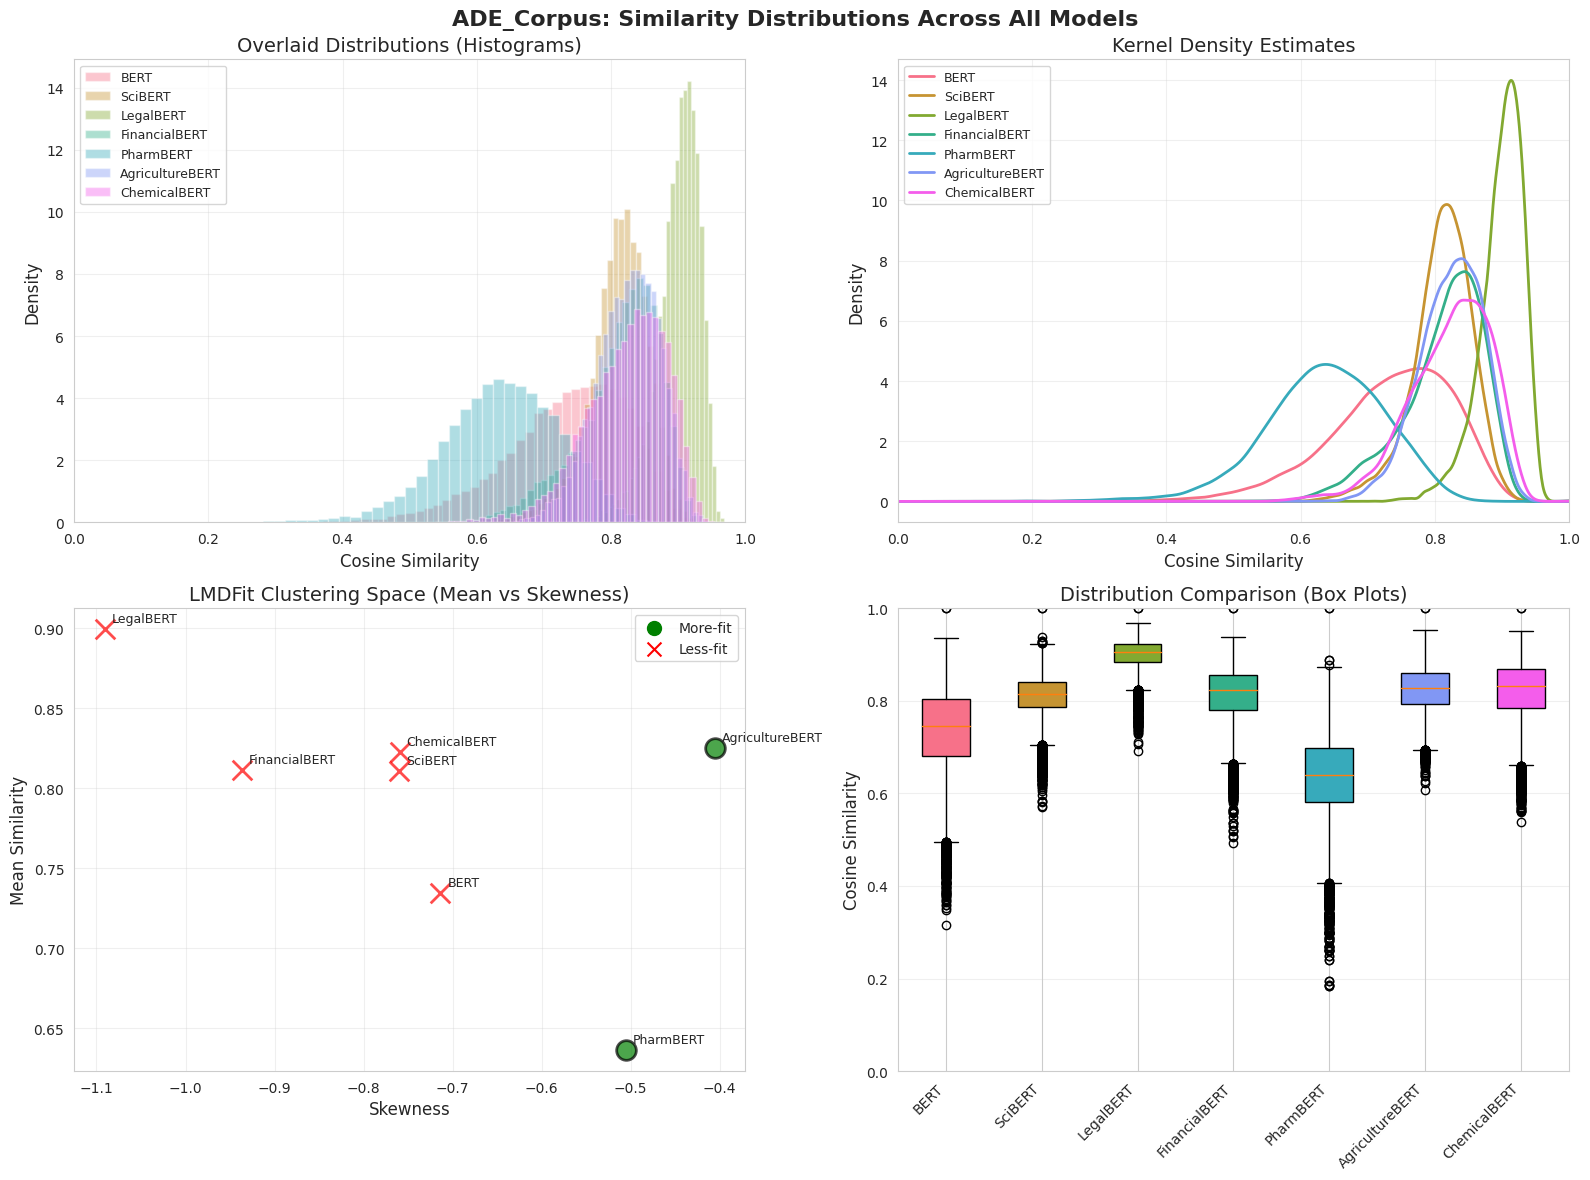

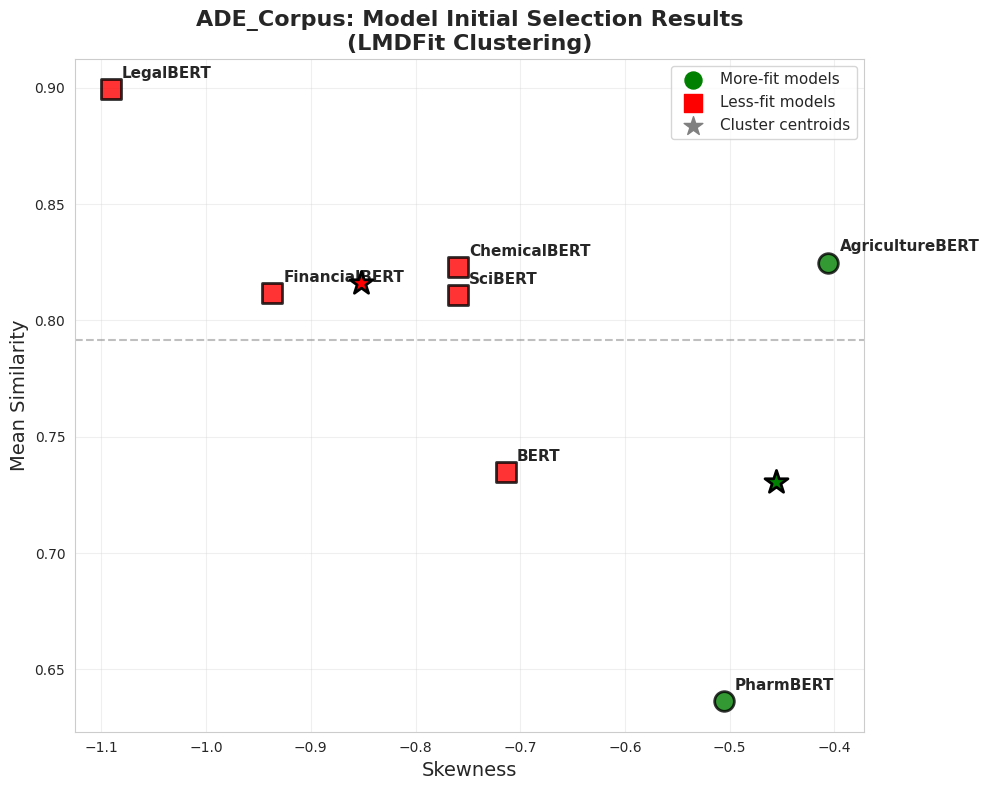

In [12]:
# Display one example visualization
if len(all_dataset_results) > 0:
    sample_dataset = list(all_dataset_results.keys())[3]
    print(f"\n📊 Sample Visualization: {sample_dataset}")
    
    fig = plot_dataset_distributions(
        sample_dataset, 
        all_dataset_results[sample_dataset],
        all_clustering_results[sample_dataset]
    )
    plt.show()
    
    fig2 = plot_clustering_scatter(
        sample_dataset,
        all_clustering_results[sample_dataset]
    )
    plt.show()

## 11. Key Insights

### What the Clustering Means:

According to the LMDFit paper:
- **More-fit models**: Have similarity distributions with skewness closer to 0, indicating balanced ability to differentiate and generalize
- **Less-fit models**: Have more negative skewness (stronger left skew), indicating either:
  - Overfitting (too much differentiation, not enough generalization)
  - Or high mean similarity (insufficient discrimination)

### Important Notes:

1. The clustering only identifies which models to EXCLUDE from benchmarking
2. It does NOT rank the "more-fit" models - you still need full benchmarking for that
3. Multi-label datasets (like ECtHR) may break LMDFit assumptions
4. Domain-specialized models may show extreme negative skewness that's actually beneficial